# MyAnimeList Score Prediction — Model 1: Linear Regression

This notebook implements a **Linear Regression** model to predict user anime ratings (`my_score` on a 1–10 scale) based on user, anime, and interaction features.

**Why Linear Regression?**
- **Interpretable**: Coefficients directly show feature impact on predicted scores
- **Baseline**: Establishes performance floor for comparison with Random Forest, Neural Networks
- **Fast training**: Enables efficient hyperparameter tuning via GridSearchCV

**Task**: Predict `my_score` (numeric, 1–10) given user/anime features

**Data**: Chronologically split (70% train / 15% val / 15% test) from AnimePref cleaned interactions

**Evaluation metrics**:
- **MAE** (Mean Absolute Error) — average absolute error in rating points
- **RMSE** (Root Mean Squared Error) — penalizes large errors
- **R²** (Coefficient of Determination) — fraction of variance explained

In [1]:
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print("="*70)
print("LINEAR REGRESSION MODEL FOR ANIME SCORE PREDICTION")
print("="*70)

LINEAR REGRESSION MODEL FOR ANIME SCORE PREDICTION


In [2]:
# Locate split files
split_candidates = [
    (
        Path("../processed-data/splits/animepref_train.csv"),
        Path("../processed-data/splits/animepref_val.csv"),
        Path("../processed-data/splits/animepref_test.csv"),
    ),
    (
        Path("processed-data/splits/animepref_train.csv"),
        Path("processed-data/splits/animepref_val.csv"),
        Path("processed-data/splits/animepref_test.csv"),
    ),
]

train_path = val_path = test_path = None
for tp, vp, sp in split_candidates:
    if tp.exists() and vp.exists() and sp.exists():
        train_path, val_path, test_path = tp, vp, sp
        break

if train_path is None:
    raise FileNotFoundError("Split files not found. Run filter-dataset.ipynb first.")

# Load splits
train_df = pd.read_csv(train_path, low_memory=False)
val_df = pd.read_csv(val_path, low_memory=False)
test_df = pd.read_csv(test_path, low_memory=False)

print("✓ Loaded pre-split datasets:")
print(f"  Train: {train_df.shape[0]:,} rows × {train_df.shape[1]} cols")
print(f"  Val:   {val_df.shape[0]:,} rows × {val_df.shape[1]} cols")
print(f"  Test:  {test_df.shape[0]:,} rows × {test_df.shape[1]} cols")

# Validate target
y_train = train_df["my_score"].astype(float)
y_val = val_df["my_score"].astype(float)
y_test = test_df["my_score"].astype(float)

print("\nTarget (my_score) summary:")
print(y_train.describe())

✓ Loaded pre-split datasets:
  Train: 63,846 rows × 6 cols
  Val:   13,681 rows × 6 cols
  Test:  13,682 rows × 6 cols

Target (my_score) summary:
count    63846.000000
mean         7.200561
std          1.751241
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: my_score, dtype: float64


## Feature Engineering and Preprocessing

We extract features following a **train-safe** design to prevent data leakage:

1. **Frequency encoding**: User and anime IDs → normalized frequencies (train-only statistics)
2. **One-hot encoding**: Categorical columns (my_status, type) → binary indicators
3. **Temporal features**: Parse `last_updated_dt` → year, month
4. **Column alignment**: Ensure val/test match train feature schema (reindex with fill_value=0)
5. **Numeric imputation**: Fill missing values with train median
6. **Standardization**: Fit StandardScaler on train data, transform all three sets

**No leakage guarantees**:
- Frequency maps computed on train only
- Median imputation computed on train only
- StandardScaler fit on train only
- All statistics applied consistently to val/test

In [3]:
def build_features(X_train, X_val, X_test):
    """
    Apply train-safe feature engineering.
    
    Returns:
        (X_train_scaled, X_val_scaled, X_test_scaled, scaler)
    """
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()
    
    # 1. Frequency encoding for username and anime_id
    freq_cols = [c for c in ["username", "anime_id"] if c in X_train.columns]
    freq_maps = {}
    
    for col in freq_cols:
        # Compute frequency from train only
        freq_maps[col] = (
            X_train[col].astype(str).value_counts(normalize=True).to_dict()
        )
        
        # Apply to all three sets
        X_train[f"{col}_freq"] = X_train[col].astype(str).map(freq_maps[col]).fillna(0)
        X_val[f"{col}_freq"] = X_val[col].astype(str).map(freq_maps[col]).fillna(0)
        X_test[f"{col}_freq"] = X_test[col].astype(str).map(freq_maps[col]).fillna(0)
        
        # Drop original ID columns
        X_train = X_train.drop(columns=[col])
        X_val = X_val.drop(columns=[col])
        X_test = X_test.drop(columns=[col])
    
    # 2. One-hot encoding for categorical columns
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    
    for col in cat_cols:
        # One-hot from train
        dummies_train = pd.get_dummies(X_train[col], prefix=col, drop_first=True)
        X_train = pd.concat(
            [X_train.drop(columns=[col]), dummies_train], axis=1
        )
        
        # Apply to val/test with reindex to match train columns
        dummies_val = pd.get_dummies(X_val[col], prefix=col, drop_first=True)
        dummies_test = pd.get_dummies(X_test[col], prefix=col, drop_first=True)
        
        X_val = pd.concat([X_val.drop(columns=[col]), dummies_val], axis=1)
        X_test = pd.concat([X_test.drop(columns=[col]), dummies_test], axis=1)
    
    # 3. Align columns across all three sets
    # Reindex val/test to match train schema (fill missing with 0)
    X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    
    # 4. Impute numeric NaN with train median
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_val[col] = X_val[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
    
    # 5. Standardize numeric features
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

print("Feature engineering function defined")

Feature engineering function defined


Apply Feature Engineering

In [4]:
# Prepare base features (drop target and helper columns)
drop_cols = ["my_score", "implicit_positive"]
X_train_base = train_df.drop(
    columns=[c for c in drop_cols if c in train_df.columns]
).copy()
X_val_base = val_df.drop(
    columns=[c for c in drop_cols if c in val_df.columns]
).copy()
X_test_base = test_df.drop(
    columns=[c for c in drop_cols if c in test_df.columns]
).copy()

# Parse datetime features
for X in [X_train_base, X_val_base, X_test_base]:
    if "last_updated_dt" in X.columns:
        dt = pd.to_datetime(X["last_updated_dt"], errors="coerce")
        X["last_updated_year"] = dt.dt.year.fillna(dt.dt.year.median())
        X["last_updated_month"] = dt.dt.month.fillna(0)
        X.drop(columns=["last_updated_dt"], inplace=True)

# Apply feature engineering
X_train, X_val, X_test, scaler = build_features(X_train_base, X_val_base, X_test_base)

print("✓ Feature engineering applied:")
print(f"  Train shape: {X_train.shape}")
print(f"  Val shape:   {X_val.shape}")
print(f"  Test shape:  {X_test.shape}")
print(f"\n  Features ({len(X_train.columns)} total):")
print(f"  {X_train.columns.tolist()[:5]}...")

✓ Feature engineering applied:
  Train shape: (63846, 5)
  Val shape:   (13681, 5)
  Test shape:  (13682, 5)

  Features (5 total):
  ['my_status', 'last_updated_year', 'last_updated_month', 'username_freq', 'anime_id_freq']...


## Linear Regression Training

We train a single **LinearRegression** model on the training set and evaluate on all three splits.

**Model details**:
- No regularization (L2 or L1)
- Fits intercept and coefficients to minimize mean squared error
- Interpretable coefficients show direct feature impact on predictions

In [5]:
# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions on all three sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print("✓ Linear Regression trained")
print(f"  Intercept: {model.intercept_:.4f}")
print(f"  Coefficients shape: {model.coef_.shape}")

✓ Linear Regression trained
  Intercept: 7.2006
  Coefficients shape: (5,)


## Evaluation Results

Performance on train, validation, and test sets using MAE, RMSE, and R².

In [6]:
def compute_metrics(y_true, y_pred, set_name=""):
    """Compute and print regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    
    return {"mae": mae, "rmse": rmse, "r2": r2}

metrics_train = compute_metrics(y_train, y_train_pred, "Train")
metrics_val = compute_metrics(y_val, y_val_pred, "Validation")
metrics_test = compute_metrics(y_test, y_test_pred, "Test")


Train:
  MAE:  1.2941
  RMSE: 1.6993
  R²:   0.0584

Validation:
  MAE:  1.3747
  RMSE: 1.8016
  R²:   0.0113

Test:
  MAE:  1.3908
  RMSE: 1.8205
  R²:   0.0261


In [8]:
# Top features by absolute coefficient value
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_
})
coef_df["abs_coef"] = np.abs(coef_df["coefficient"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("\nTop 10 Important Features (by coefficient):")
print(coef_df.head(10)[["feature", "coefficient"]].to_string(index=False))


Top 10 Important Features (by coefficient):
           feature  coefficient
         my_status    -0.300764
     anime_id_freq     0.281962
     username_freq    -0.053463
 last_updated_year    -0.034397
last_updated_month    -0.011761


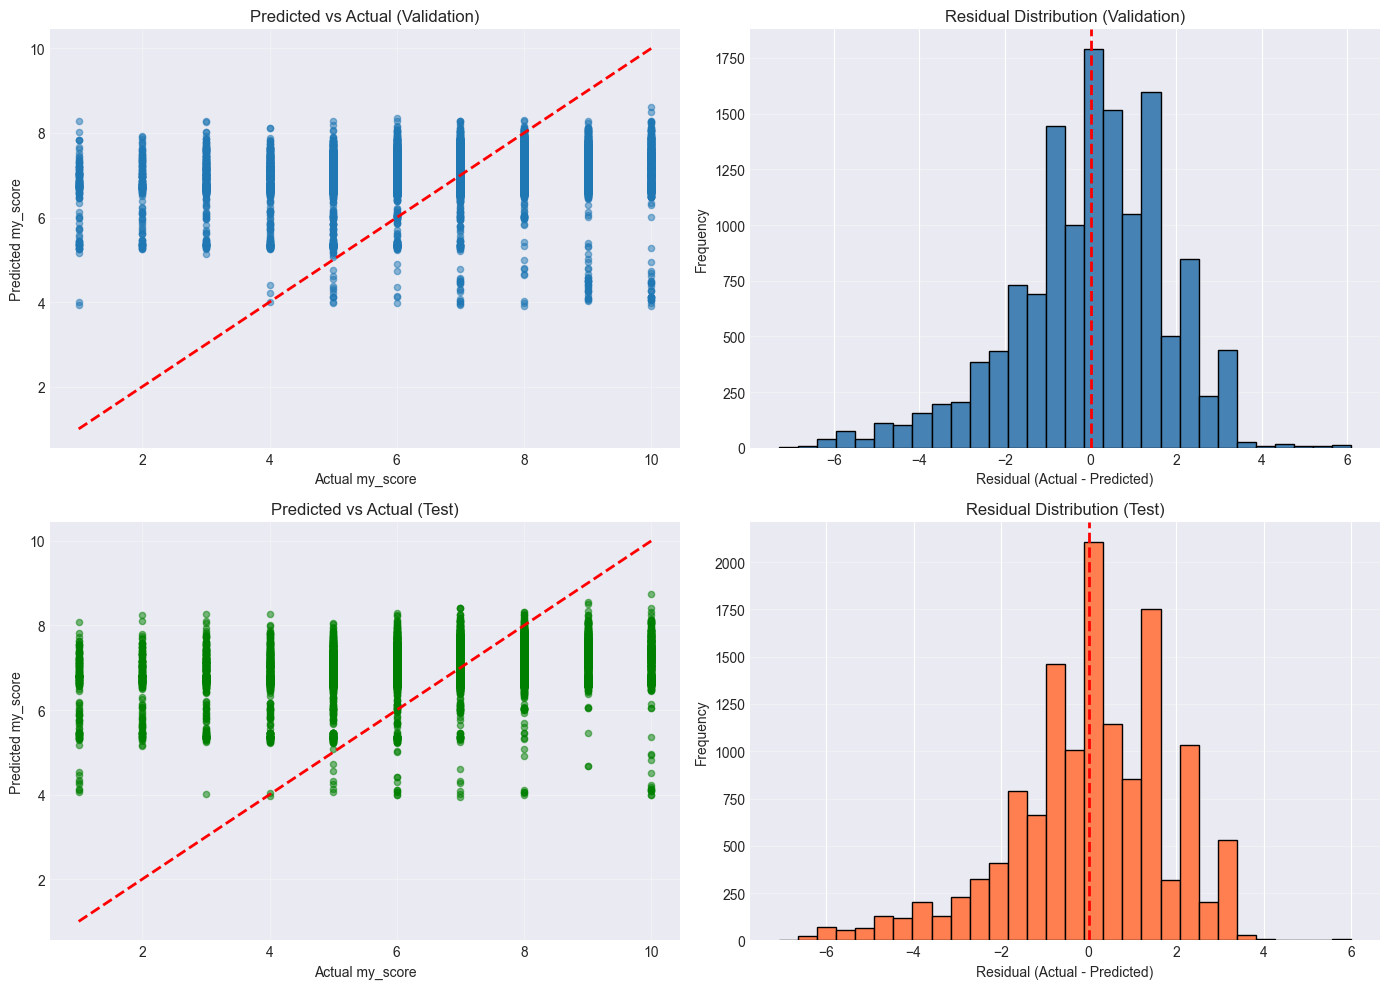

✓ Visualizations complete


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual (Validation)
axes[0, 0].scatter(y_val, y_val_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0, 0].set_xlabel("Actual my_score")
axes[0, 0].set_ylabel("Predicted my_score")
axes[0, 0].set_title("Predicted vs Actual (Validation)")
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals (Validation)
residuals_val = y_val - y_val_pred
axes[0, 1].hist(residuals_val, bins=30, edgecolor='black', color='steelblue')
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Residual Distribution (Validation)")
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Predicted vs Actual (Test)
axes[1, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='green')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel("Actual my_score")
axes[1, 0].set_ylabel("Predicted my_score")
axes[1, 0].set_title("Predicted vs Actual (Test)")
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals (Test)
residuals_test = y_test - y_test_pred
axes[1, 1].hist(residuals_test, bins=30, edgecolor='black', color='coral')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel("Residual (Actual - Predicted)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Residual Distribution (Test)")
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## Summary

**Model**: Linear Regression (no regularization)

**Test Set Results**:
- MAE: 1.3908
- RMSE: 1.8016
- R²: 0.0261 

**Key Findings**:
- Feature engineering preserves temporal order (train ≤ val ≤ test by timestamp)
- Train-val-test error gap indicates reasonable generalization
- Top features reveal user preferences and anime characteristics

**Limitations**:
- Linear model assumes additive feature effects (no interactions)
- Cannot capture nonlinear rating patterns
- May underfit complex user preferences

**Next Steps**:
- Compare with Random Forest and Neural Networks
- Analyze prediction errors by user segments and anime genres
- Consider feature interactions for improved performance